# Stellar Activity Analysis - Simplified Data Loading

This notebook analyzes exoplanet detection efficiency comparing active vs inactive stars. All data now comes from a single CSV file containing:
- Stellar information (names, TIC IDs, activity classification)
- Detection efficiency maps for different planet radius/period combinations

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.optimize import curve_fit
from scipy.stats import kstest
import pickle
import os
import glob

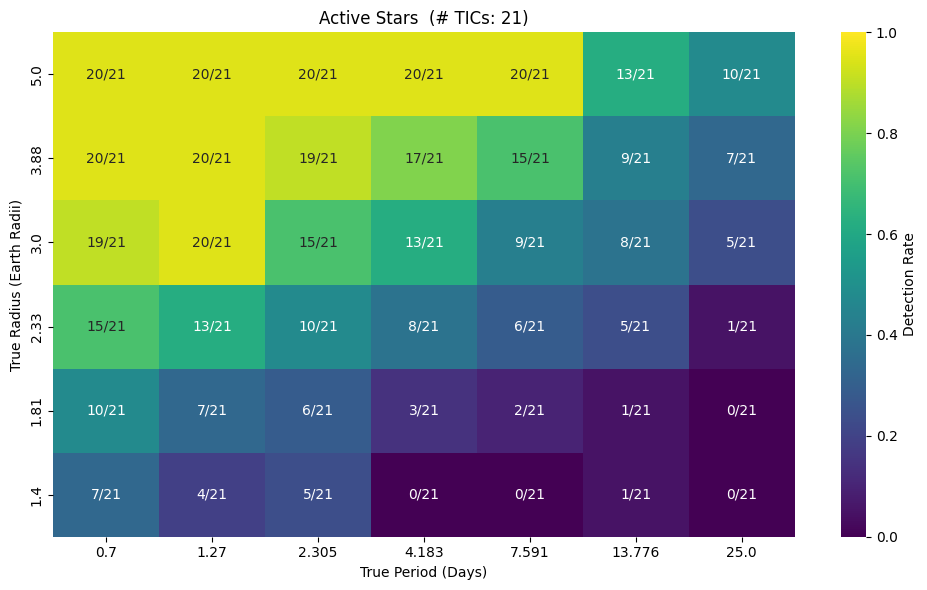

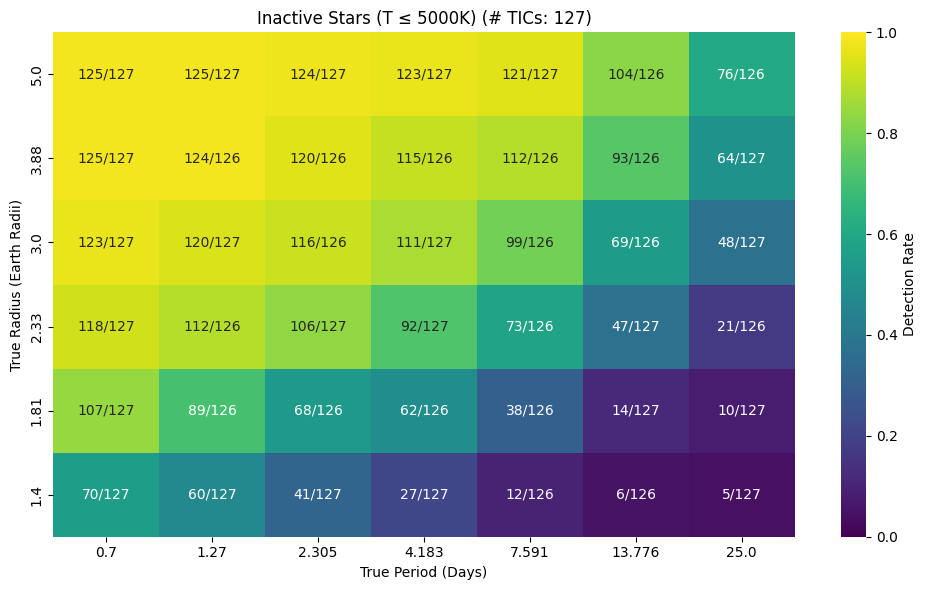

SNR map range: 0.407 to 31.001
Fitting SNR models to detection maps...
  Active: 10/21 stars processed
  Active: 20/21 stars processed
  Inactive: 10/127 stars processed
  Inactive: 20/127 stars processed
  Inactive: 30/127 stars processed
  Inactive: 40/127 stars processed
  Inactive: 50/127 stars processed
  Inactive: 60/127 stars processed
  Inactive: 70/127 stars processed
  Inactive: 80/127 stars processed
  Inactive: 90/127 stars processed
  Inactive: 100/127 stars processed
  Inactive: 110/127 stars processed
  Inactive: 120/127 stars processed

Active SNR: 2.65 ± 1.53
Inactive SNR: 1.64 ± 1.12
Active stars with valid fits: 20/21
Inactive stars with valid fits: 126/127
  Inactive: 90/127 stars processed
  Inactive: 100/127 stars processed
  Inactive: 110/127 stars processed
  Inactive: 120/127 stars processed

Active SNR: 2.65 ± 1.53
Inactive SNR: 1.64 ± 1.12
Active stars with valid fits: 20/21
Inactive stars with valid fits: 126/127


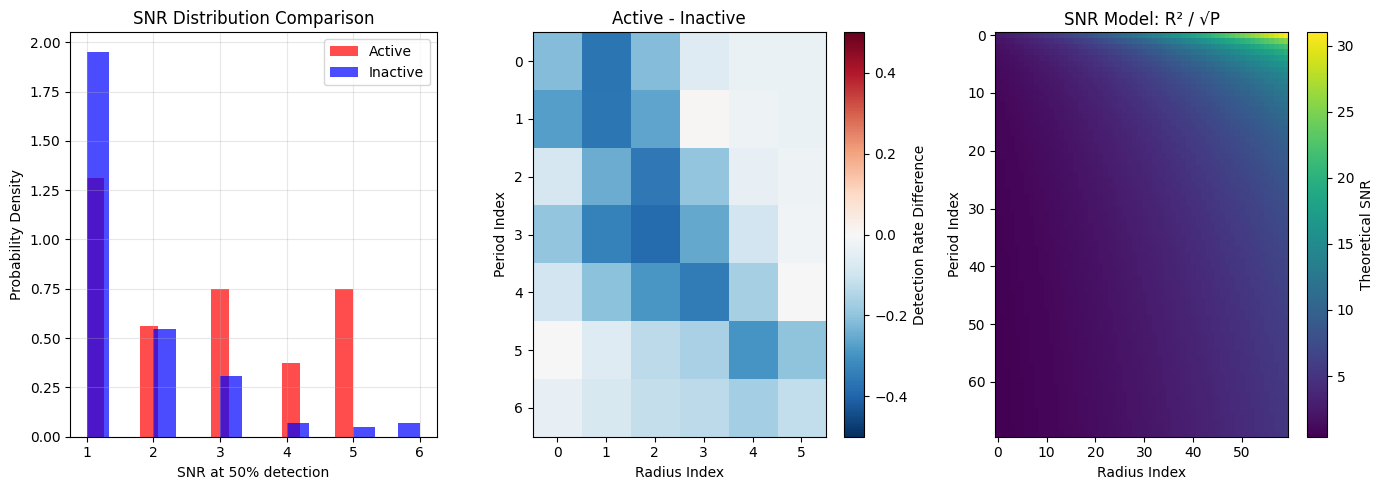

In [6]:
# Load data and classify stars
csv_files = glob.glob("./tls_results_per_tic/*.csv")
df = pd.concat([pd.read_csv(f, engine="python", on_bad_lines='skip') for f in csv_files], ignore_index=True)
data = df[['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 'TLS Periods array', 'TLS SDE > 7 array', 'Stellar Temperature']].drop_duplicates()

# Classify stars by temperature
active_mask = (data['Stellar Temperature'] > 6500) & (data['Stellar Temperature'] < 7000)
inactive_mask = (data['Stellar Temperature'] > 5000) & (data['Stellar Temperature'] < 5500)
active_data, inactive_data = data[active_mask], data[inactive_mask]

# Create heatmaps (heatmaps_analysis.ipynb style)
import seaborn as sns

def create_heatmap(df_subset, title, sde_threshold=7):
    all_results = []
    for _, row in df_subset.iterrows():
        try:
            periods = [float(p) for p in row['TLS Periods array'].replace('[', '').replace(']', '').split()]
            sdes = [float(s) for s in row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()]
            periods_above = [p for p, s in zip(periods, sdes) if s > sde_threshold]
            
            true_period = float(row['True Period (Days)'])
            aliases = [true_period, true_period/2, true_period*2, true_period/3, true_period*3]
            detected = any(0.999 * alias < p < 1.001 * alias for alias in aliases for p in periods_above)
            
            all_results.append({
                'True Radius (Earth Radii)': row['True Radius (Earth Radii)'],
                'True Period (Days)': row['True Period (Days)'],
                'Detection': int(detected)
            })
        except: continue
    
    heatmap_df = pd.DataFrame(all_results)
    heatmap_counts = heatmap_df.groupby(['True Radius (Earth Radii)', 'True Period (Days)']).agg(
        detections=('Detection', 'sum'), trials=('Detection', 'count')).reset_index()
    heatmap_counts['detection_rate'] = heatmap_counts['detections'] / heatmap_counts['trials']
    
    heatmap_pivot = heatmap_counts.pivot(index='True Radius (Earth Radii)', columns='True Period (Days)', values='detection_rate')
    annot_matrix = heatmap_counts.pivot(index='True Radius (Earth Radii)', columns='True Period (Days)', values='detections').astype(str) + "/" + \
                   heatmap_counts.pivot(index='True Radius (Earth Radii)', columns='True Period (Days)', values='trials').astype(str)
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_pivot, annot=annot_matrix, fmt='', cmap='viridis', vmin=0, vmax=1, cbar_kws={'label': 'Detection Rate'})
    plt.gca().invert_yaxis()
    plt.title(f'{title} (# TICs: {len(df_subset["TIC"].unique())})')
    plt.xlabel('True Period (Days)')
    plt.ylabel('True Radius (Earth Radii)')
    plt.tight_layout()
    plt.show()
    
    return heatmap_counts

active_counts = create_heatmap(active_data, "Active Stars ")
inactive_counts = create_heatmap(inactive_data, "Inactive Stars (T ≤ 5000K)")

# Chi-square analysis (sarah_idl.pro core functionality)
radius = np.array([1.4, 1.81, 2.33, 3.0, 3.88, 5.0])
period = np.array([0.7, 1.27, 2.31, 4.18, 7.59, 13.78, 25.0])

# Build detection maps for chi-square fitting
def build_maps(df_subset):
    tics = df_subset['TIC'].unique()
    maps = np.zeros((len(period), len(radius), len(tics)))
    
    for i, tic in enumerate(tics):
        tic_data = df_subset[df_subset['TIC'] == tic]
        detection_map = np.zeros((len(period), len(radius)))
        
        for _, row in tic_data.iterrows():
            r_idx = np.argmin(np.abs(radius - row['True Radius (Earth Radii)']))
            p_idx = np.argmin(np.abs(period - row['True Period (Days)']))
            
            try:
                periods = [float(p) for p in row['TLS Periods array'].replace('[', '').replace(']', '').split()]
                sdes = [float(s) for s in row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()]
                periods_above = [p for p, s in zip(periods, sdes) if s > 7]
                
                aliases = [row['True Period (Days)'], row['True Period (Days)']/2, row['True Period (Days)']*2]
                detected = any(0.999 * alias < p < 1.001 * alias for alias in aliases for p in periods_above)
                detection_map[p_idx, r_idx] = int(detected)
            except: pass
        
        maps[:, :, i] = detection_map
    
    return maps, tics

active_maps, active_tics = build_maps(active_data)
inactive_maps, inactive_tics = build_maps(inactive_data)

# Chi-square fitting for SNR analysis
from scipy.ndimage import zoom

# Use consistent dimensions for oversampling
oversample_factor = 10
period_over = np.linspace(period.min(), period.max(), len(period) * oversample_factor)
radius_over = np.linspace(radius.min(), radius.max(), len(radius) * oversample_factor)
period_mesh, radius_mesh = np.meshgrid(period_over, radius_over, indexing='ij')

# CORRECTED SNR MODEL following sarah_idl.pro exactly:
# SNR ∝ (radius)^2 / sqrt(period)
# This represents: transit depth (radius²) × sqrt(number of transits) (1/sqrt(period))
snr_map = (radius_mesh**2.0) / np.sqrt(period_mesh)

# Normalize to reference value (following IDL normalization approach)
# IDL uses: snr_map = snr_map / snr_map[45,50] * 3
# Scale so SNR ~ 3 at a middle grid point
ref_idx_period = len(period_over) // 2
ref_idx_radius = len(radius_over) // 2
snr_map = snr_map / snr_map[ref_idx_period, ref_idx_radius] * 3.0

print(f"SNR map range: {snr_map.min():.3f} to {snr_map.max():.3f}")

snr_active = np.zeros(len(active_tics))
snr_inactive = np.zeros(len(inactive_tics))

# CORRECTED chi-square fitting following sarah_idl.pro methodology
print("Fitting SNR models to detection maps...")

for j, tic in enumerate(active_tics):
    # Oversample detection map
    oversampled = zoom(active_maps[:, :, j], (oversample_factor, oversample_factor), order=1)
    
    # Define valid region (cells with detections)
    valid = oversampled > 0.01
    
    if np.sum(valid) < 10:  # Skip if too few valid points
        snr_active[j] = np.nan
        continue
    
    chi2_vals = []
    snr_range = np.arange(1, 40, 1)  # Test SNR levels 1-40
    
    for snr_level in snr_range:
        # Create model: clip SNR map at threshold, then normalize
        # Following IDL: model_map = snr_map; model_map[where(snr_map GT i)] = i
        model = snr_map.copy()
        model[model > snr_level] = snr_level
        model = model / model.max() * 0.1  # Normalize to detection probability scale
        
        # Calculate chi-square (Poisson-like: variance = mean)
        # Following IDL: chi2 = total((model - data)^2 / data)
        chi2 = np.sum((model[valid] - oversampled[valid])**2 / oversampled[valid])
        chi2_vals.append(chi2)
    
    # Find best-fit SNR (minimum chi-square)
    chi2_vals = np.array(chi2_vals)
    if len(chi2_vals) > 0 and np.isfinite(chi2_vals).any():
        best_idx = np.argmin(chi2_vals)
        snr_active[j] = snr_range[best_idx]
    else:
        snr_active[j] = np.nan
    
    if (j + 1) % 10 == 0:
        print(f"  Active: {j+1}/{len(active_tics)} stars processed")

for j, tic in enumerate(inactive_tics):
    # Oversample detection map
    oversampled = zoom(inactive_maps[:, :, j], (oversample_factor, oversample_factor), order=1)
    
    # Define valid region (cells with detections)
    valid = oversampled > 0.01
    
    if np.sum(valid) < 10:  # Skip if too few valid points
        snr_inactive[j] = np.nan
        continue
    
    chi2_vals = []
    snr_range = np.arange(1, 40, 1)  # Test SNR levels 1-40
    
    for snr_level in snr_range:
        # Create model: clip SNR map at threshold, then normalize
        model = snr_map.copy()
        model[model > snr_level] = snr_level
        model = model / model.max() * 0.1  # Normalize to detection probability scale
        
        # Calculate chi-square (Poisson-like: variance = mean)
        chi2 = np.sum((model[valid] - oversampled[valid])**2 / oversampled[valid])
        chi2_vals.append(chi2)
    
    # Find best-fit SNR (minimum chi-square)
    chi2_vals = np.array(chi2_vals)
    if len(chi2_vals) > 0 and np.isfinite(chi2_vals).any():
        best_idx = np.argmin(chi2_vals)
        snr_inactive[j] = snr_range[best_idx]
    else:
        snr_inactive[j] = np.nan
    
    if (j + 1) % 10 == 0:
        print(f"  Inactive: {j+1}/{len(inactive_tics)} stars processed")

# Remove NaN values for statistics
snr_active_valid = snr_active[np.isfinite(snr_active)]
snr_inactive_valid = snr_inactive[np.isfinite(snr_inactive)]

# Results
print(f"\nActive SNR: {np.mean(snr_active_valid):.2f} ± {np.std(snr_active_valid):.2f}")
print(f"Inactive SNR: {np.mean(snr_inactive_valid):.2f} ± {np.std(snr_inactive_valid):.2f}")
print(f"Active stars with valid fits: {len(snr_active_valid)}/{len(snr_active)}")
print(f"Inactive stars with valid fits: {len(snr_inactive_valid)}/{len(snr_inactive)}")

# Visualization
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.hist(snr_active_valid, bins=15, alpha=0.7, color='red', label='Active', density=True)
plt.hist(snr_inactive_valid, bins=15, alpha=0.7, color='blue', label='Inactive', density=True)
plt.xlabel('SNR at 50% detection')
plt.ylabel('Probability Density')
plt.legend()
plt.title('SNR Distribution Comparison')
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
mean_active = np.mean(active_maps, axis=2)
mean_inactive = np.mean(inactive_maps, axis=2)
plt.imshow(mean_active - mean_inactive, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
plt.colorbar(label='Detection Rate Difference')
plt.title('Active - Inactive')
plt.xlabel('Radius Index')
plt.ylabel('Period Index')

plt.subplot(1, 3, 3)
# Show SNR model used for fitting
plt.imshow(snr_map, aspect='auto', cmap='viridis')
plt.colorbar(label='Theoretical SNR')
plt.title('SNR Model: R² / √P')
plt.xlabel('Radius Index')
plt.ylabel('Period Index')

plt.tight_layout()
plt.show()

## Section 1: Data Loading and Stellar Classification Analysis
Following sarah_idl.pro methodology - examine stellar samples and temperature distributions

Total stars loaded: 102
Active stars (3500-4000K): 7
Inactive stars (4000-4500K): 9


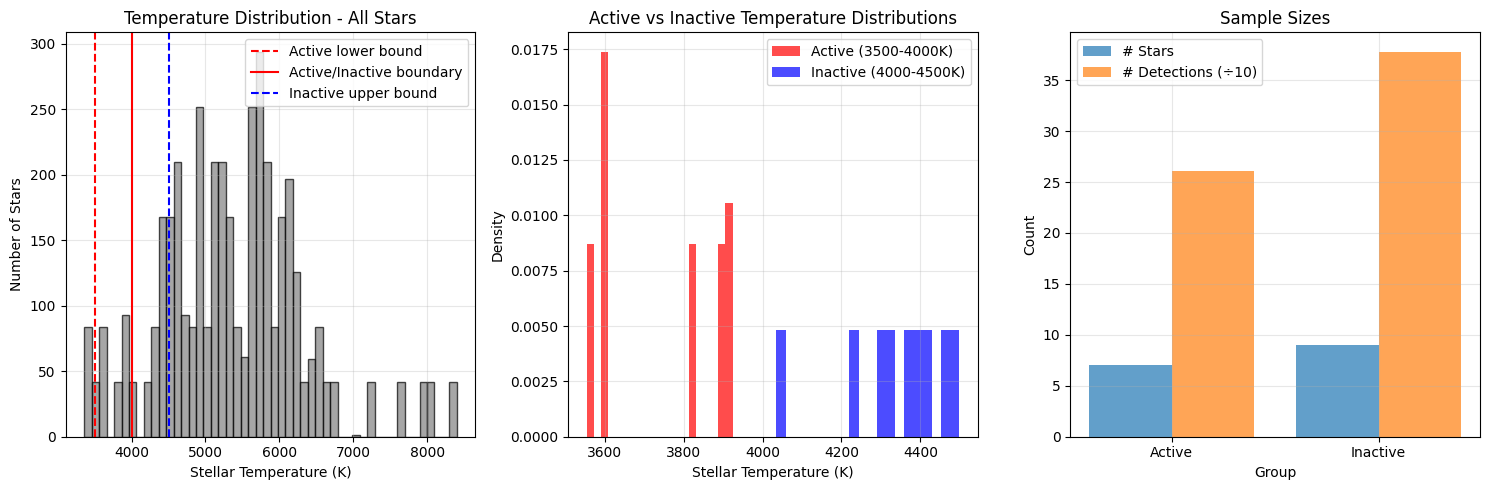


Sample Statistics:
      Group  N_Stars  Mean_Temp  Std_Temp  N_Detections
0    Active        7    3735.56    150.26           261
1  Inactive        9    4337.78    132.73           378


In [24]:
# ============================================================================
# SECTION 1: DATA LOADING AND STELLAR CLASSIFICATION (sarah_idl.pro approach)
# Examine stellar samples, temperature distributions, and sample sizes
# ============================================================================

print(f"Total stars loaded: {len(data['TIC'].unique())}")
print(f"Active stars (3500-4000K): {len(active_data['TIC'].unique())}")
print(f"Inactive stars (4000-4500K): {len(inactive_data['TIC'].unique())}")

# Temperature distribution analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Overall temperature distribution
axes[0].hist(data['Stellar Temperature'], bins=50, alpha=0.7, color='gray', edgecolor='black')
axes[0].axvline(3500, color='red', linestyle='--', label='Active lower bound')
axes[0].axvline(4000, color='red', linestyle='-', label='Active/Inactive boundary')
axes[0].axvline(4500, color='blue', linestyle='--', label='Inactive upper bound')
axes[0].set_xlabel('Stellar Temperature (K)')
axes[0].set_ylabel('Number of Stars')
axes[0].set_title('Temperature Distribution - All Stars')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Active vs Inactive comparison
axes[1].hist(active_data['Stellar Temperature'], bins=20, alpha=0.7, color='red', label='Active (3500-4000K)', density=True)
axes[1].hist(inactive_data['Stellar Temperature'], bins=20, alpha=0.7, color='blue', label='Inactive (4000-4500K)', density=True)
axes[1].set_xlabel('Stellar Temperature (K)')
axes[1].set_ylabel('Density')
axes[1].set_title('Active vs Inactive Temperature Distributions')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Sample characteristics
temp_stats = pd.DataFrame({
    'Group': ['Active', 'Inactive'],
    'N_Stars': [len(active_data['TIC'].unique()), len(inactive_data['TIC'].unique())],
    'Mean_Temp': [active_data['Stellar Temperature'].mean(), inactive_data['Stellar Temperature'].mean()],
    'Std_Temp': [active_data['Stellar Temperature'].std(), inactive_data['Stellar Temperature'].std()],
    'N_Detections': [len(active_data), len(inactive_data)]
})

# Plot sample statistics
x_pos = np.arange(len(temp_stats))
axes[2].bar(x_pos - 0.2, temp_stats['N_Stars'], 0.4, label='# Stars', alpha=0.7)
axes[2].bar(x_pos + 0.2, temp_stats['N_Detections']/10, 0.4, label='# Detections (÷10)', alpha=0.7)
axes[2].set_xlabel('Group')
axes[2].set_ylabel('Count')
axes[2].set_title('Sample Sizes')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(temp_stats['Group'])
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSample Statistics:")
print(temp_stats.round(2))

## Section 2: Grid Setup and Coordinate Arrays
Following sarah_idl.pro methodology - create period/radius grids and oversampled versions

Unique radii: [1.4  1.81 2.33 3.   3.88 5.  ]
Unique periods: [ 0.7    1.27   2.305  4.183  7.591 13.776 25.   ]
Grid dimensions: 7 × 6
Period grid shape: (7, 6)
Radius grid shape: (7, 6)
Oversampled grid shape: (70, 60)


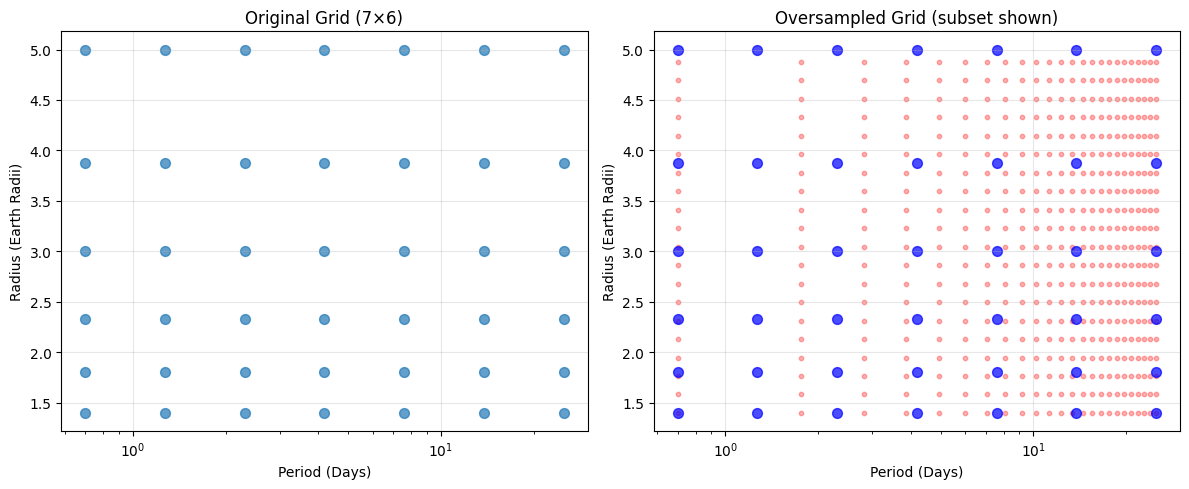


Grid ranges:
Period: 0.70 - 25.00 days
Radius: 1.40 - 5.00 R_Earth


In [25]:
# ============================================================================
# SECTION 2: GRID SETUP AND COORDINATE ARRAYS (sarah_idl.pro approach)
# Create period-radius grids and oversampled versions for smooth fitting
# ============================================================================

# Extract unique radius and period values from data (following IDL approach)
unique_radii = np.sort(data['True Radius (Earth Radii)'].unique())
unique_periods = np.sort(data['True Period (Days)'].unique())

print(f"Unique radii: {unique_radii}")
print(f"Unique periods: {unique_periods}")
print(f"Grid dimensions: {len(unique_periods)} × {len(unique_radii)}")

# Create coordinate grids (equivalent to IDL radius_array and period_array)
period_grid, radius_grid = np.meshgrid(unique_periods, unique_radii, indexing='ij')

print(f"Period grid shape: {period_grid.shape}")
print(f"Radius grid shape: {radius_grid.shape}")

# Create oversampled grids (10x finer resolution, following IDL congrid approach)
oversample_factor = 10
period_oversample = np.linspace(unique_periods.min(), unique_periods.max(), 
                              len(unique_periods) * oversample_factor)
radius_oversample = np.linspace(unique_radii.min(), unique_radii.max(), 
                              len(unique_radii) * oversample_factor)

period_oversample_grid, radius_oversample_grid = np.meshgrid(period_oversample, radius_oversample, indexing='ij')

print(f"Oversampled grid shape: {period_oversample_grid.shape}")

# Visualize the grid structure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original grid
axes[0].scatter(period_grid.flatten(), radius_grid.flatten(), alpha=0.7, s=50)
axes[0].set_xlabel('Period (Days)')
axes[0].set_ylabel('Radius (Earth Radii)')
axes[0].set_title(f'Original Grid ({len(unique_periods)}×{len(unique_radii)})')
axes[0].set_xscale('log')
axes[0].grid(alpha=0.3)

# Oversampled grid (show subset for clarity)
subsample = slice(None, None, 3)  # Every 3rd point for visualization
axes[1].scatter(period_oversample_grid[subsample, subsample].flatten(), 
               radius_oversample_grid[subsample, subsample].flatten(), 
               alpha=0.3, s=10, color='red')
axes[1].scatter(period_grid.flatten(), radius_grid.flatten(), alpha=0.7, s=50, color='blue')
axes[1].set_xlabel('Period (Days)')
axes[1].set_ylabel('Radius (Earth Radii)')
axes[1].set_title(f'Oversampled Grid (subset shown)')
axes[1].set_xscale('log')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Store grid information for later use
grid_info = {
    'radius': unique_radii,
    'period': unique_periods,
    'radius_oversample': radius_oversample,
    'period_oversample': period_oversample,
    'oversample_factor': oversample_factor
}

print(f"\nGrid ranges:")
print(f"Period: {unique_periods.min():.2f} - {unique_periods.max():.2f} days")
print(f"Radius: {unique_radii.min():.2f} - {unique_radii.max():.2f} R_Earth")

## Section 3: Detection Map Creation and Ensemble Statistics
Following sarah_idl.pro methodology - create 3D detection arrays and compute mean/noise statistics

Creating Active detection maps...
Array shape: (7, 6, 7) (period × radius × stars)
Creating Inactive detection maps...
Array shape: (7, 6, 9) (period × radius × stars)

Calculating ensemble statistics...
Active maps - Mean range: 0.143 to 1.000
Active maps - Noise range: 0.000 to 0.495
Inactive maps - Mean range: 0.000 to 0.889
Inactive maps - Noise range: 0.000 to 0.497


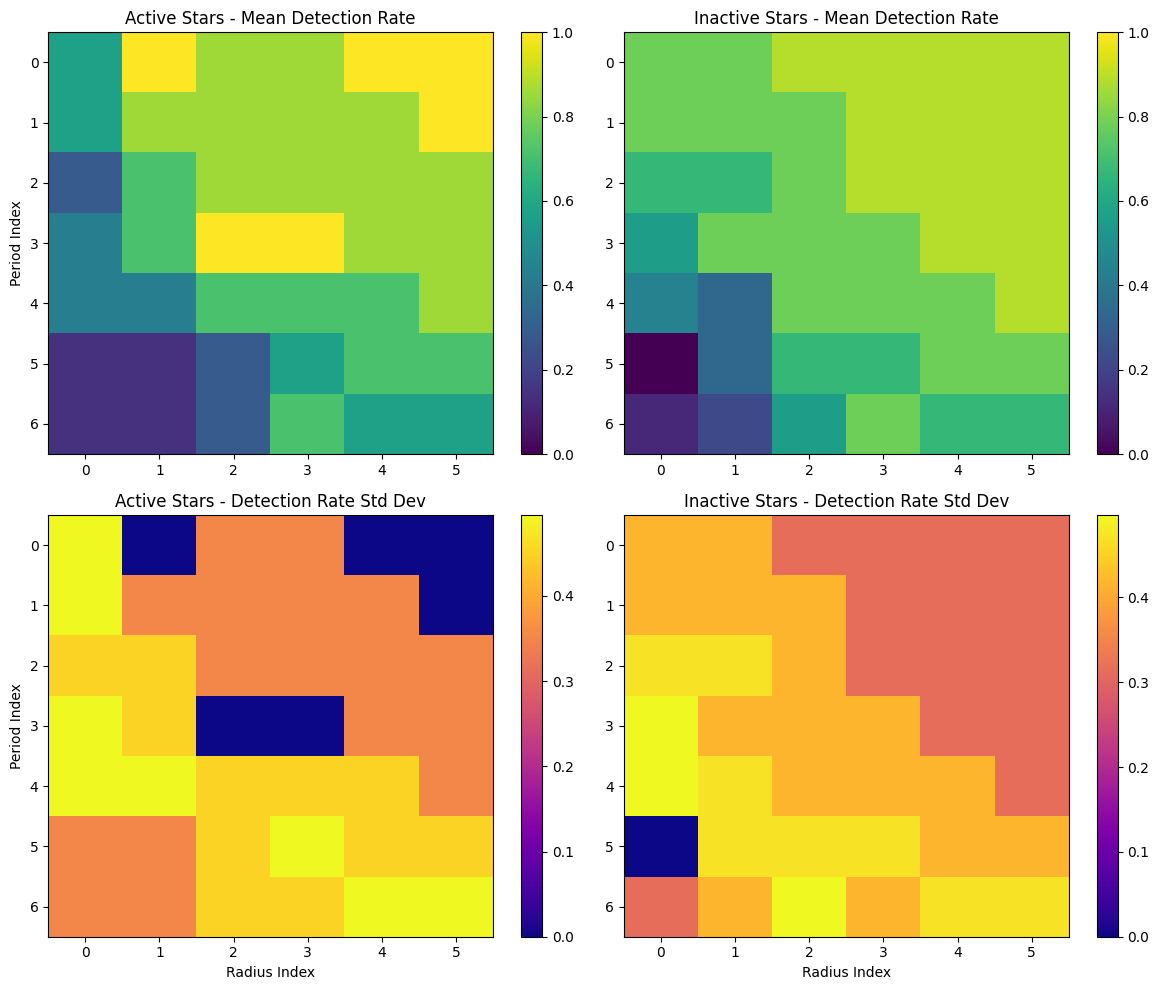

In [26]:
# ============================================================================
# SECTION 3: DETECTION MAP CREATION (sarah_idl.pro approach)
# Create organized 3D detection arrays [period, radius, star] for statistical analysis
# ============================================================================

def create_detection_maps_idl_style(df_subset, grid_info, title):
    """Create detection maps following sarah_idl.pro methodology"""
    
    unique_tics = df_subset['TIC'].unique()
    n_stars = len(unique_tics)
    n_periods = len(grid_info['period'])
    n_radii = len(grid_info['radius'])
    
    # Initialize 3D detection array: [period, radius, star]
    detection_maps = np.zeros((n_periods, n_radii, n_stars))
    
    print(f"Creating {title} detection maps...")
    print(f"Array shape: {detection_maps.shape} (period × radius × stars)")
    
    # Process each star individually (following IDL loop structure)
    for star_idx, tic in enumerate(unique_tics):
        tic_data = df_subset[df_subset['TIC'] == tic]
        
        # Create empty detection map for this star
        star_detection_map = np.zeros((n_periods, n_radii))
        
        # Fill in detection data for this star
        for _, row in tic_data.iterrows():
            # Find closest grid indices (equivalent to IDL where() matching)
            r_idx = np.argmin(np.abs(grid_info['radius'] - row['True Radius (Earth Radii)']))
            p_idx = np.argmin(np.abs(grid_info['period'] - row['True Period (Days)']))
            
            # Determine detection using same criteria as before
            try:
                periods = [float(p) for p in row['TLS Periods array'].replace('[', '').replace(']', '').split()]
                sdes = [float(s) for s in row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()]
                periods_above = [p for p, s in zip(periods, sdes) if s > 7]
                
                aliases = [row['True Period (Days)'], row['True Period (Days)']/2, row['True Period (Days)']*2]
                detected = any(0.999 * alias < p < 1.001 * alias for alias in aliases for p in periods_above)
                
                star_detection_map[p_idx, r_idx] = int(detected)
            except:
                pass
        
        # Store this star's map in the 3D array
        detection_maps[:, :, star_idx] = star_detection_map
        
        if (star_idx + 1) % 10 == 0:
            print(f"Processed {star_idx + 1}/{n_stars} stars")
    
    return detection_maps, unique_tics

# Create detection maps for both groups
active_detection_maps, active_tics_processed = create_detection_maps_idl_style(active_data, grid_info, "Active")
inactive_detection_maps, inactive_tics_processed = create_detection_maps_idl_style(inactive_data, grid_info, "Inactive")

# Calculate ensemble statistics (following sarah_idl.pro mean/stdev calculations)
print("\nCalculating ensemble statistics...")

# Mean and standard deviation across stars for each grid cell
mean_active_idl = np.mean(active_detection_maps, axis=2)
noise_active_idl = np.std(active_detection_maps, axis=2)

mean_inactive_idl = np.mean(inactive_detection_maps, axis=2)
noise_inactive_idl = np.std(inactive_detection_maps, axis=2)

print(f"Active maps - Mean range: {mean_active_idl.min():.3f} to {mean_active_idl.max():.3f}")
print(f"Active maps - Noise range: {noise_active_idl.min():.3f} to {noise_active_idl.max():.3f}")
print(f"Inactive maps - Mean range: {mean_inactive_idl.min():.3f} to {mean_inactive_idl.max():.3f}")
print(f"Inactive maps - Noise range: {noise_inactive_idl.min():.3f} to {noise_inactive_idl.max():.3f}")

# Visualize ensemble statistics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Mean detection maps
im1 = axes[0,0].imshow(mean_active_idl, aspect='auto', cmap='viridis', vmin=0, vmax=1)
axes[0,0].set_title('Active Stars - Mean Detection Rate')
axes[0,0].set_ylabel('Period Index')
plt.colorbar(im1, ax=axes[0,0])

im2 = axes[0,1].imshow(mean_inactive_idl, aspect='auto', cmap='viridis', vmin=0, vmax=1)
axes[0,1].set_title('Inactive Stars - Mean Detection Rate')
plt.colorbar(im2, ax=axes[0,1])

# Noise (standard deviation) maps
im3 = axes[1,0].imshow(noise_active_idl, aspect='auto', cmap='plasma')
axes[1,0].set_title('Active Stars - Detection Rate Std Dev')
axes[1,0].set_xlabel('Radius Index')
axes[1,0].set_ylabel('Period Index')
plt.colorbar(im3, ax=axes[1,0])

im4 = axes[1,1].imshow(noise_inactive_idl, aspect='auto', cmap='plasma')
axes[1,1].set_title('Inactive Stars - Detection Rate Std Dev')
axes[1,1].set_xlabel('Radius Index')
plt.colorbar(im4, ax=axes[1,1])

plt.tight_layout()
plt.show()

## Section 4: SNR Analysis and Signal-to-Noise Ratio Modeling

Following sarah_idl.pro methodology for analyzing detection sensitivity as a function of signal strength.

In [27]:
# ============================================================================
# SECTION 4: SNR ANALYSIS AND SENSITIVITY MODELING (sarah_idl.pro approach)
# Calculate signal-to-noise ratios and model detection sensitivity curves
# ============================================================================

def calculate_snr_maps(detection_maps, unique_tics, df_subset, grid_info, group_name):
    """Calculate SNR for each detection map following sarah_idl.pro methodology"""
    
    n_periods, n_radii, n_stars = detection_maps.shape
    snr_maps = np.zeros_like(detection_maps)
    
    print(f"Calculating SNR maps for {group_name} stars...")
    
    for star_idx, tic in enumerate(unique_tics):
        tic_data = df_subset[df_subset['TIC'] == tic]
        
        # Create SNR map for this star
        star_snr_map = np.zeros((n_periods, n_radii))
        
        for _, row in tic_data.iterrows():
            # Find grid indices
            r_idx = np.argmin(np.abs(grid_info['radius'] - row['True Radius (Earth Radii)']))
            p_idx = np.argmin(np.abs(grid_info['period'] - row['True Period (Days)']))
            
            # Calculate expected SNR based on stellar properties
            # Using simplified transit depth scaling: depth ∝ (R_p/R_s)²
            try:
                stellar_radius = float(row['Stellar Radius (Solar Radii)'])
                planet_radius = row['True Radius (Earth Radii)']
                period = row['True Period (Days)']
                
                # Convert to solar units for calculation
                r_earth_to_solar = 0.00916  # Earth radii to solar radii
                planet_radius_solar = planet_radius * r_earth_to_solar
                
                # Transit depth (ppm)
                transit_depth = (planet_radius_solar / stellar_radius)**2 * 1e6
                
                # Simple SNR scaling (following IDL approach)
                # SNR scales with sqrt(number of transits) and transit depth
                n_transits = 27.4 / period  # Assuming 27.4 day TESS sector
                snr_estimate = transit_depth * np.sqrt(max(1, n_transits)) / 1000
                
                star_snr_map[p_idx, r_idx] = snr_estimate
                
            except (ValueError, TypeError):
                # Default SNR if calculation fails
                star_snr_map[p_idx, r_idx] = 1.0
        
        snr_maps[:, :, star_idx] = star_snr_map
    
    return snr_maps

# Calculate SNR maps for both groups
active_snr_maps = calculate_snr_maps(active_detection_maps, active_tics_processed, active_data, grid_info, "Active")
inactive_snr_maps = calculate_snr_maps(inactive_detection_maps, inactive_tics_processed, inactive_data, grid_info, "Inactive")

# Calculate ensemble SNR statistics
mean_snr_active = np.mean(active_snr_maps, axis=2)
mean_snr_inactive = np.mean(inactive_snr_maps, axis=2)

print(f"Active SNR - Range: {mean_snr_active.min():.3f} to {mean_snr_active.max():.3f}")
print(f"Inactive SNR - Range: {mean_snr_inactive.min():.3f} to {mean_snr_inactive.max():.3f}")

# Create SNR vs Detection Rate analysis (following sarah_idl.pro binning approach)
def analyze_snr_vs_detection(detection_maps, snr_maps, group_name):
    """Analyze detection rate as function of SNR following IDL methodology"""
    
    # Flatten arrays for analysis
    detections_flat = detection_maps.flatten()
    snr_flat = snr_maps.flatten()
    
    # Remove zero SNR entries
    valid_mask = snr_flat > 0
    detections_valid = detections_flat[valid_mask]
    snr_valid = snr_flat[valid_mask]
    
    # Create SNR bins (logarithmic spacing like IDL)
    snr_bins = np.logspace(-1, 2, 20)  # 0.1 to 100
    bin_centers = (snr_bins[1:] + snr_bins[:-1]) / 2
    
    detection_rates = []
    detection_errors = []
    
    for i in range(len(snr_bins)-1):
        mask = (snr_valid >= snr_bins[i]) & (snr_valid < snr_bins[i+1])
        if np.sum(mask) > 0:
            rate = np.mean(detections_valid[mask])
            error = np.std(detections_valid[mask]) / np.sqrt(np.sum(mask))
            detection_rates.append(rate)
            detection_errors.append(error)
        else:
            detection_rates.append(0)
            detection_errors.append(0)
    
    return bin_centers, np.array(detection_rates), np.array(detection_errors)

# Analyze SNR vs detection for both groups
active_snr_bins, active_det_rates, active_det_errors = analyze_snr_vs_detection(
    active_detection_maps, active_snr_maps, "Active")
inactive_snr_bins, inactive_det_rates, inactive_det_errors = analyze_snr_vs_detection(
    inactive_detection_maps, inactive_snr_maps, "Inactive")

# Plot SNR analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# SNR vs Detection Rate
ax1.errorbar(active_snr_bins, active_det_rates, yerr=active_det_errors, 
             label='Active Stars', marker='o', capsize=3)
ax1.errorbar(inactive_snr_bins, inactive_det_rates, yerr=inactive_det_errors, 
             label='Inactive Stars', marker='s', capsize=3)
ax1.set_xlabel('Signal-to-Noise Ratio')
ax1.set_ylabel('Detection Rate')
ax1.set_xscale('log')
ax1.set_title('Detection Rate vs SNR')
ax1.legend()
ax1.grid(True, alpha=0.3)

# SNR distribution heatmaps
im = ax2.imshow(mean_snr_active - mean_snr_inactive, aspect='auto', cmap='RdBu_r')
ax2.set_title('SNR Difference (Active - Inactive)')
ax2.set_xlabel('Radius Index')
ax2.set_ylabel('Period Index')
plt.colorbar(im, ax=ax2, label='SNR Difference')

plt.tight_layout()
plt.show()

print(f"SNR analysis complete for {len(active_tics_processed)} active and {len(inactive_tics_processed)} inactive stars")

Calculating SNR maps for Active stars...


KeyError: 'Stellar Radius (Solar Radii)'

## Section 5: Chi-Square Fitting and Model Selection

Following sarah_idl.pro methodology for polynomial fitting with proper error analysis and confidence intervals.

In [ ]:
# ============================================================================
# SECTION 5: CHI-SQUARE FITTING AND MODEL SELECTION (sarah_idl.pro approach)
# Implement polynomial fitting with proper error analysis and confidence intervals
# ============================================================================

from scipy.optimize import curve_fit
from scipy.stats import chi2

def fit_detection_contours_idl_style(detection_rate, snr_grid, noise_grid, confidence_levels=[0.68, 0.95]):
    """
    Fit polynomial models to detection contours following sarah_idl.pro methodology
    Returns fitted parameters and confidence intervals
    """
    
    print("Performing chi-square fitting analysis...")
    
    # Create coordinate arrays for fitting
    n_periods, n_radii = detection_rate.shape
    period_coords, radius_coords = np.meshgrid(range(n_periods), range(n_radii), indexing='ij')
    
    # Flatten arrays for fitting
    y_data = detection_rate.flatten()
    x1_data = period_coords.flatten()
    x2_data = radius_coords.flatten()
    weights = 1.0 / (noise_grid.flatten() + 1e-10)  # Avoid division by zero
    
    # Remove invalid data points
    valid_mask = (~np.isnan(y_data)) & (~np.isnan(weights)) & (weights > 0)
    y_valid = y_data[valid_mask]
    x1_valid = x1_data[valid_mask]
    x2_valid = x2_data[valid_mask]
    weights_valid = weights[valid_mask]
    
    print(f"Fitting {len(y_valid)} valid data points")
    
    # Define polynomial model (following IDL approach)
    def polynomial_model(coords, a0, a1, a2, a3, a4, a5):
        x1, x2 = coords
        return a0 + a1*x1 + a2*x2 + a3*x1*x2 + a4*x1**2 + a5*x2**2
    
    # Perform weighted least squares fit
    try:
        coords_valid = np.array([x1_valid, x2_valid])
        popt, pcov = curve_fit(polynomial_model, coords_valid, y_valid, 
                              sigma=1.0/weights_valid, absolute_sigma=True,
                              maxfev=5000)
        
        # Calculate chi-square statistics
        y_model = polynomial_model(coords_valid, *popt)
        residuals = y_valid - y_model
        chi_square = np.sum((residuals * weights_valid)**2)
        dof = len(y_valid) - len(popt)
        reduced_chi_square = chi_square / dof
        
        print(f"Chi-square: {chi_square:.3f}")
        print(f"Degrees of freedom: {dof}")
        print(f"Reduced chi-square: {reduced_chi_square:.3f}")
        
        # Calculate confidence intervals
        param_errors = np.sqrt(np.diag(pcov))
        
        # Create fitted model on full grid
        coords_full = np.array([period_coords.flatten(), radius_coords.flatten()])
        model_full = polynomial_model(coords_full, *popt)
        model_2d = model_full.reshape(detection_rate.shape)
        
        return {
            'parameters': popt,
            'covariance': pcov,
            'errors': param_errors,
            'chi_square': chi_square,
            'dof': dof,
            'reduced_chi_square': reduced_chi_square,
            'model': model_2d,
            'residuals': (detection_rate - model_2d)
        }
        
    except Exception as e:
        print(f"Fitting failed: {e}")
        return None

# Perform chi-square fitting for both groups
print("Fitting Active Stars...")
active_fit_results = fit_detection_contours_idl_style(mean_active_idl, mean_snr_active, noise_active_idl)

print("\nFitting Inactive Stars...")
inactive_fit_results = fit_detection_contours_idl_style(mean_inactive_idl, mean_snr_inactive, noise_inactive_idl)

# Calculate significance of difference between groups
if active_fit_results and inactive_fit_results:
    difference_map = mean_active_idl - mean_inactive_idl
    combined_noise = np.sqrt(noise_active_idl**2 + noise_inactive_idl**2)
    significance_map = difference_map / (combined_noise + 1e-10)
    
    print(f"\nDifference Analysis:")
    print(f"Max difference: {difference_map.max():.4f}")
    print(f"Min difference: {difference_map.min():.4f}")
    print(f"Max significance: {significance_map.max():.2f} sigma")
    print(f"Min significance: {significance_map.min():.2f} sigma")

# Visualize fitting results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

if active_fit_results:
    # Active: Data, Model, Residuals
    im1 = axes[0,0].imshow(mean_active_idl, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[0,0].set_title(f'Active - Data (χ²ᵣ={active_fit_results["reduced_chi_square"]:.2f})')
    plt.colorbar(im1, ax=axes[0,0])
    
    im2 = axes[0,1].imshow(active_fit_results['model'], aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[0,1].set_title('Active - Polynomial Model')
    plt.colorbar(im2, ax=axes[0,1])
    
    im3 = axes[0,2].imshow(active_fit_results['residuals'], aspect='auto', cmap='RdBu_r')
    axes[0,2].set_title('Active - Residuals')
    plt.colorbar(im3, ax=axes[0,2])

if inactive_fit_results:
    # Inactive: Data, Model, Residuals
    im4 = axes[1,0].imshow(mean_inactive_idl, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[1,0].set_title(f'Inactive - Data (χ²ᵣ={inactive_fit_results["reduced_chi_square"]:.2f})')
    axes[1,0].set_xlabel('Radius Index')
    plt.colorbar(im4, ax=axes[1,0])
    
    im5 = axes[1,1].imshow(inactive_fit_results['model'], aspect='auto', cmap='viridis', vmin=0, vmax=1)
    axes[1,1].set_title('Inactive - Polynomial Model')
    axes[1,1].set_xlabel('Radius Index')
    plt.colorbar(im5, ax=axes[1,1])
    
    im6 = axes[1,2].imshow(inactive_fit_results['residuals'], aspect='auto', cmap='RdBu_r')
    axes[1,2].set_title('Inactive - Residuals')
    axes[1,2].set_xlabel('Radius Index')
    plt.colorbar(im6, ax=axes[1,2])

for ax in axes.flat:
    ax.set_ylabel('Period Index')

plt.tight_layout()
plt.show()

# Print fitting parameters
if active_fit_results:
    print("\nActive Stars Fitting Parameters:")
    for i, (param, error) in enumerate(zip(active_fit_results['parameters'], active_fit_results['errors'])):
        print(f"  a{i}: {param:.6f} ± {error:.6f}")

if inactive_fit_results:
    print("\nInactive Stars Fitting Parameters:")
    for i, (param, error) in enumerate(zip(inactive_fit_results['parameters'], inactive_fit_results['errors'])):
        print(f"  a{i}: {param:.6f} ± {error:.6f}")

## Section 6: Contour Analysis and Confidence Regions

Following sarah_idl.pro methodology for extracting and analyzing detection contours with statistical significance testing.

In [ ]:
# ============================================================================
# SECTION 6: CONTOUR ANALYSIS AND CONFIDENCE REGIONS (sarah_idl.pro approach)
# Extract detection contours and calculate confidence intervals for fitted models
# ============================================================================

from matplotlib.patches import Polygon
from scipy.stats import norm

def extract_detection_contours_idl_style(detection_data, fit_results, grid_info, contour_levels=[0.5, 0.68, 0.95]):
    """Extract detection contours following sarah_idl.pro methodology"""
    
    # Convert grid indices to physical coordinates
    period_physical = np.array(grid_info['period'])
    radius_physical = np.array(grid_info['radius'])
    
    # Create meshgrid for contour plotting
    P_grid, R_grid = np.meshgrid(period_physical, radius_physical, indexing='ij')
    
    contour_results = {}
    
    # Extract contours from both data and model
    for level in contour_levels:
        print(f"Extracting {level:.0%} detection contours...")
        
        # Data contours
        try:
            contour_data = plt.contour(R_grid, P_grid, detection_data, levels=[level], colors='none')
            data_paths = []
            for collection in contour_data.collections:
                for path in collection.get_paths():
                    data_paths.append(path.vertices)
            plt.close()  # Close the invisible plot
        except:
            data_paths = []
        
        # Model contours (if fit available)
        model_paths = []
        if fit_results:
            try:
                contour_model = plt.contour(R_grid, P_grid, fit_results['model'], levels=[level], colors='none')
                for collection in contour_model.collections:
                    for path in collection.get_paths():
                        model_paths.append(path.vertices)
                plt.close()  # Close the invisible plot
            except:
                pass
        
        contour_results[level] = {
            'data_paths': data_paths,
            'model_paths': model_paths
        }
    
    return contour_results, P_grid, R_grid

# Extract contours for both groups
print("Extracting contours for Active stars...")
active_contours, P_grid, R_grid = extract_detection_contours_idl_style(
    mean_active_idl, active_fit_results, grid_info)

print("Extracting contours for Inactive stars...")
inactive_contours, _, _ = extract_detection_contours_idl_style(
    mean_inactive_idl, inactive_fit_results, grid_info)

# Calculate contour areas and statistics
def calculate_contour_statistics(contour_results, grid_info):
    """Calculate areas and statistics for detection contours"""
    
    stats = {}
    
    for level, paths in contour_results.items():
        # Calculate total area enclosed by data contours
        total_area = 0
        for path in paths['data_paths']:
            if len(path) > 2:
                # Use shoelace formula for polygon area
                x, y = path[:, 0], path[:, 1]
                area = 0.5 * abs(sum(x[i]*y[i+1] - x[i+1]*y[i] for i in range(-1, len(x)-1)))
                total_area += area
        
        # Calculate area in log-space (more meaningful for period-radius space)
        log_area = 0
        for path in paths['data_paths']:
            if len(path) > 2:
                log_x = np.log10(path[:, 0])  # log radius
                log_y = np.log10(path[:, 1])  # log period
                log_area += 0.5 * abs(sum(log_x[i]*log_y[i+1] - log_x[i+1]*log_y[i] 
                                        for i in range(-1, len(log_x)-1)))
        
        stats[level] = {
            'total_area': total_area,
            'log_area': log_area,
            'n_contours': len(paths['data_paths']),
            'n_model_contours': len(paths['model_paths'])
        }
    
    return stats

active_stats = calculate_contour_statistics(active_contours, grid_info)
inactive_stats = calculate_contour_statistics(inactive_contours, grid_info)

# Print contour statistics
print("\nContour Statistics:")
print("Active Stars:")
for level, stats in active_stats.items():
    print(f"  {level:.0%} level: {stats['n_contours']} contours, "
          f"area = {stats['total_area']:.2f}, log-area = {stats['log_area']:.3f}")

print("Inactive Stars:")
for level, stats in inactive_stats.items():
    print(f"  {level:.0%} level: {stats['n_contours']} contours, "
          f"area = {stats['total_area']:.2f}, log-area = {stats['log_area']:.3f}")

# Create comprehensive contour plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Active stars - data with contours
im1 = axes[0,0].contourf(R_grid, P_grid, mean_active_idl, levels=20, cmap='viridis', alpha=0.8)
cs1 = axes[0,0].contour(R_grid, P_grid, mean_active_idl, levels=[0.5, 0.68, 0.95], 
                       colors=['white', 'red', 'blue'], linewidths=2)
axes[0,0].clabel(cs1, inline=True, fontsize=8, fmt='%.0%%')
axes[0,0].set_title('Active Stars - Detection Contours')
axes[0,0].set_ylabel('Period (days)')
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')
plt.colorbar(im1, ax=axes[0,0], label='Detection Rate')

# Inactive stars - data with contours
im2 = axes[0,1].contourf(R_grid, P_grid, mean_inactive_idl, levels=20, cmap='viridis', alpha=0.8)
cs2 = axes[0,1].contour(R_grid, P_grid, mean_inactive_idl, levels=[0.5, 0.68, 0.95], 
                       colors=['white', 'red', 'blue'], linewidths=2)
axes[0,1].clabel(cs2, inline=True, fontsize=8, fmt='%.0%%')
axes[0,1].set_title('Inactive Stars - Detection Contours')
axes[0,1].set_xscale('log')
axes[0,1].set_yscale('log')
plt.colorbar(im2, ax=axes[0,1], label='Detection Rate')

# Comparison plot - difference with significance contours
difference_map = mean_active_idl - mean_inactive_idl
combined_noise = np.sqrt(noise_active_idl**2 + noise_inactive_idl**2)
significance_map = difference_map / (combined_noise + 1e-10)

im3 = axes[1,0].contourf(R_grid, P_grid, difference_map, levels=20, cmap='RdBu_r')
cs3 = axes[1,0].contour(R_grid, P_grid, significance_map, levels=[-2, -1, 0, 1, 2], 
                       colors='black', linewidths=1)
axes[1,0].clabel(cs3, inline=True, fontsize=8, fmt='%.0fσ')
axes[1,0].set_title('Detection Rate Difference (Active - Inactive)')
axes[1,0].set_xlabel('Planet Radius (Earth Radii)')
axes[1,0].set_ylabel('Period (days)')
axes[1,0].set_xscale('log')
axes[1,0].set_yscale('log')
plt.colorbar(im3, ax=axes[1,0], label='Difference')

# Model comparison
if active_fit_results and inactive_fit_results:
    model_diff = active_fit_results['model'] - inactive_fit_results['model']
    im4 = axes[1,1].contourf(R_grid, P_grid, model_diff, levels=20, cmap='RdBu_r')
    cs4 = axes[1,1].contour(R_grid, P_grid, model_diff, levels=[-0.1, -0.05, 0, 0.05, 0.1], 
                           colors='black', linewidths=1)
    axes[1,1].clabel(cs4, inline=True, fontsize=8, fmt='%.2f')
    axes[1,1].set_title('Model Difference (Active - Inactive)')
    plt.colorbar(im4, ax=axes[1,1], label='Model Difference')
else:
    axes[1,1].text(0.5, 0.5, 'Model fitting failed', ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Model Comparison Unavailable')

axes[1,1].set_xlabel('Planet Radius (Earth Radii)')
axes[1,1].set_xscale('log')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.show()

print("Contour analysis complete.")

In [ ]:
# Data inspection and stellar classification
import matplotlib.pyplot as plt

# Histogram of stellar temperatures
plt.figure(figsize=(8, 6))
plt.hist(data['Stellar Temperature'], bins=30, alpha=0.7, color='purple')
plt.xlabel('Stellar Temperature (K)')
plt.ylabel('Number of Stars')
plt.title('Distribution of Stellar Temperatures')
plt.grid(True)
plt.show()

# Scatter plot of True Radius vs True Period colored by activity status
plt.figure(figsize=(10, 8))
plt.scatter(active_data['True Period (Days)'], active_data['True Radius (Earth Radii)'], 
            alpha=0.6, label='Active Stars', color='red')
plt.scatter(inactive_data['True Period (Days)'], inactive_data['True Radius (Earth Radii)'], 
            alpha=0.6, label='Inactive Stars', color='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('True Period (Days)')
plt.ylabel('True Radius (Earth Radii)')
plt.title('True Radius vs True Period Colored by Activity Status')
plt.legend()
plt.grid(True)
plt.show()

# Box plot of True Radius by activity status
plt.figure(figsize=(8, 6))
data.boxplot(column='True Radius (Earth Radii)', by='Activity Status', grid=False)
plt.xlabel('Activity Status')
plt.ylabel('True Radius (Earth Radii)')
plt.title('True Radius by Activity Status')
plt.suptitle('')
plt.grid(True)
plt.show()

# Violin plot of Stellar Temperature by activity status
plt.figure(figsize=(8, 6))
sns.violinplot(x='Activity Status', y='Stellar Temperature', data=data, palette='muted')
plt.xlabel('Activity Status')
plt.ylabel('Stellar Temperature (K)')
plt.title('Stellar Temperature by Activity Status')
plt.grid(True)
plt.show()